#0. Introduzione
In questo notebook vengono addestrati e valutati diversi modelli di classificazione, con l’obiettivo di identificare quello più efficace nella predizione delle classi target in uno studio sui disturbi neuropsichiatrici. L’obiettivo principale è massimizzare la balanced accuracy, in quanto il dataset presenta un marcato sbilanciamento tra le classi.

La balanced accuracy, in particolare, calcola la media del recall per ogni classe, dando lo stesso peso a tutte, anche se sono sbilanciate.

Il dataset è già stato oggetto di analisi esplorativa e preprocessamento in una fase precedente, pertanto le sue caratteristiche non vengono qui descritte nel dettaglio.

Per l’addestramento dei modelli sono utilizzate tutte le features eccetto quelle che terminano con _ESITO, utilizzate solo per calcolare i valori _PG mancanti. Al fine di garantire una validazione corretta e priva di data leakage tra i fold, è stata costruita una pipeline di preprocessing che include: imputazione dei valori mancanti, codifica delle variabili categoriche e normalizzazione delle variabili numeriche.

Il codice è progettato per essere flessibile e adattabile sia a problemi di classificazione binaria che multiclasse.

#1. Caricamento librerie
In questa sezione sono state caricate tutte le librerie utilizzate.

In [1]:
# Installazione librerie esterne
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.8 MB/s eta 0:00:00


In [2]:
# Librerie per la manipolazione dei dati
import pandas as pd
import numpy as np

# Librerie per la visualizzazione
import matplotlib.pyplot as plt
import seaborn as sns

# Librerie per il preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.pipeline import Pipeline

# Librerie per la selezione e validazione del modello
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# Librerie per la valutazione del modello
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    balanced_accuracy_score,
    f1_score,
    make_scorer
)

# Librerie per modelli di classificazione
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier, RandomForestRegressor
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

# Librerie per costruzione pipeline e bilanciamento classi
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

# Librerie per gestione di warnings
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

#2. Definizione funzioni per la pipeline e per la valutazione dei modelli
Il codice seguente definisce una serie di trasformatori personalizzati, una pipeline di modellazione supervisionata e una funzione di valutazione delle performance, con particolare attenzione alla gestione intelligente dei valori mancanti e alla corretta validazione del modello.

L’uso di una pipeline assicura che tutte le operazioni di preprocessing (come imputazione, encoding, scaling, bilanciamento, ecc.) vengano eseguite in modo coerente sia durante l’addestramento che nella fase di test o validazione incrociata. Questo approccio previene errori comuni, come il data leakage, ovvero l’uso involontario di informazioni del test set durante il training, che potrebbe produrre metriche artificialmente alte e non realistiche.

In particolare, vengono definiti tre trasformatori personalizzati per l’imputazione dei valori mancanti:

- CategoricalESITOImputer: imputazione delle colonne categoriche che terminano con _ESITO utilizzando la moda (valore più frequente), ideale per variabili target-like o di riferimento categoriale.

- PGEsitoImputer: imputazione dei valori mancanti nelle colonne numeriche che terminano con _PG, sfruttando la statistica aggregata (es. mediana) calcolata per ciascuna categoria nella rispettiva colonna _ESITO. Questa strategia mantiene la coerenza semantica tra le due variabili e si basa sulla relazione tra esito e punteggio.

- IterativePGImputer: imputazione iterativa basata su Random Forest per le colonne _PG, in grado di stimare i valori mancanti residui sfruttando la correlazione tra tutte le colonne numeriche. Questo passaggio è essenziale soprattutto durante la validazione incrociata: in alcuni fold, può mancare completamente una combinazione _PG/_ESITO, impedendo l’imputazione tramite mediana. In questi casi, l’approccio iterativo garantisce la completa imputazione senza introdurre bias.

Inoltre, si definisce un ulteriore trasformatore:

- DropEsitoColumns: rimozione finale delle colonne _ESITO, ormai non più necessarie dopo la fase di imputazione, per evitare che influenzino la modellazione.

Tutti questi passaggi vengono integrati nella funzione build_pipeline, che restituisce una pipeline ImbPipeline composta da:

- Imputazione intelligente (categorie e numeri),

- Preprocessing (scaling, encoding, ecc.),

- Bilanciamento delle classi con SMOTETomek,

- Classificatore supervisionato finale (es. RandomForest, SVM, ecc.).

Infine, la funzione evaluate_model fornisce una valutazione completa delle prestazioni del modello. Include:

- Visualizzazione delle metriche di validazione incrociata ottimali ottenute tramite ricerca degli iperparametri,

- Calcolo di metriche sul test set: Accuratezza Bilanciata, F1-macro e ROC AUC,

- Report di classificazione dettagliato e matrice di confusione visualizzata tramite heatmap.

Tutte le funzioni sono compatibili con problemi di classificazione binaria e multiclasse.

In [3]:
# Classe per imputare i valori mancanti delle colonne *_PG in base alla mediana (o altro metodo) calcolata per ogni categoria nella colonna corrispondente *_ESITO
class PGEsitoImputer(BaseEstimator, TransformerMixin):
    def __init__(self, method='median'):
        self.method = method
        self.fill_values_ = {}

    def fit(self, X, y=None):
        # Per ogni colonna che termina con '_PG', cerca la corrispondente colonna '_ESITO'
        for col in X.columns:
            if col.endswith('_PG'):
                esito_col = col.replace('_PG', '_ESITO')
                if esito_col in X.columns:
                    # Crea un sotto-dataset senza valori mancanti
                    sub = X[[col, esito_col]].dropna()
                    # Calcola la mediana (o altro metodo) del valore _PG raggruppato per _ESITO
                    agg = sub.groupby(esito_col)[col].agg(self.method)
                    # Salva i valori calcolati per l'imputazione successiva
                    self.fill_values_[col] = agg
        return self

    def transform(self, X):
        check_is_fitted(self, 'fill_values_')
        X = X.copy()
        # Per ogni colonna _PG con valori mancanti, prova a imputare usando il valore corrispondente in _ESITO
        for pg_col, mapping in self.fill_values_.items():
            esito_col = pg_col.replace('_PG', '_ESITO')
            mask = X[pg_col].isna() & X[esito_col].notna()
            X.loc[mask, pg_col] = X.loc[mask, esito_col].map(mapping)
        return X

# Classe per Imputer avanzato per le colonne *_PG basato su IterativeImputer con Random Forest
class IterativePGImputer(BaseEstimator, TransformerMixin):
    def __init__(self, max_iter=50, random_state=42, n_estimators=5):
        self.max_iter = max_iter
        self.random_state = random_state
        self.n_estimators = n_estimators
        self.imputer = None  # sarà creato in fit()

    def fit(self, X, y=None):
        # Seleziona solo le colonne con suffisso '_PG'
        self.pg_cols = [c for c in X.columns if c.endswith('_PG')]
        # Crea un IterativeImputer con regressore RandomForest
        self.imputer = IterativeImputer(
            estimator=RandomForestRegressor(
                n_estimators=self.n_estimators,
                random_state=self.random_state
            ),
            max_iter=self.max_iter,
            random_state=self.random_state
        )
        # Adatta l’imputer sui dati disponibili delle colonne '_PG'
        self.imputer.fit(X[self.pg_cols])
        return self

    def transform(self, X):
        check_is_fitted(self.imputer)
        X = X.copy()
        # Imputa i valori mancanti con i valori predetti
        imputed = self.imputer.transform(X[self.pg_cols])
        for i, col in enumerate(self.pg_cols):
            mask = X[col].isna()
            X.loc[mask, col] = imputed[mask, i]
        return X

# Classe per imputare i valori mancanti delle colonne categoriche *_ESITO usando la moda (valore più frequente)
class CategoricalESITOImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Seleziona tutte le colonne categoriche che terminano con '_ESITO'
        self.esito_cols = [c for c in X.columns if c.endswith('_ESITO')]
        # Crea un imputatore per ogni colonna con strategia 'most_frequent'
        self.imputers = {
            col: SimpleImputer(strategy='most_frequent').fit(X[[col]])
            for col in self.esito_cols
        }
        return self

    def transform(self, X):
        check_is_fitted(self, 'imputers')
        X = X.copy()
        # Applica ogni imputatore alla rispettiva colonna
        for col, imputer in self.imputers.items():
            if col in X.columns:
                X[[col]] = imputer.transform(X[[col]])
        return X

# Classe per rimuovere le colonne che terminano con _ESITO
class DropEsitoColumns(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Identifica tutte le colonne con suffisso '_ESITO' da eliminare
        self.cols_to_drop_ = [c for c in X.columns if c.endswith('_ESITO')]
        return self

    def transform(self, X):
        X = X.copy()
        # Rimuove le colonne '_ESITO' dal dataset
        return X.drop(columns=self.cols_to_drop_, errors='ignore')


# Funzione per la costruzione della pipeline completa
def build_pipeline(classifier):
    return ImbPipeline(steps=[
        ('categorical_esito_imputer', CategoricalESITOImputer()),  # Imputa le colonne categoriche *_ESITO
        ('pg_esito_imputer', PGEsitoImputer()),                    # Imputa *_PG usando *_ESITO
        ('iterative_pg_imputer', IterativePGImputer()),            # Imputazione avanzata su *_PG
        ('drop_esito', DropEsitoColumns()),                        # Rimuove le colonne *_ESITO
        ('preprocessor', preprocessor),                            # Preprocessing
        ('sampling', SMOTETomek(random_state=42)),                 # Bilanciamento classi
        ('classifier', classifier)                                 # Modello finale
    ])


# Funzione per la valutazione dei modelli
def evaluate_model(search, X_test, y_test, class_labels, le=None, is_multiclass=False):
    best_model = search.best_estimator_

    # Se è presente un label encoder, decodifica i target
    if le is not None:
        y_test_encoded = le.transform(y_test)
        y_pred = best_model.predict(X_test)
        y_pred_labels = le.inverse_transform(y_pred)
        y_proba = best_model.predict_proba(X_test)
        y_test_eval = y_test_encoded
        y_pred_eval = y_pred
        y_pred_print = y_pred_labels
    else:
        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)
        y_test_eval = y_test
        y_pred_eval = y_pred
        y_pred_print = y_pred

    # Stampa i punteggi di cross-validazione migliori
    print("\n=== Best cross-validation scores ===")
    best_idx = search.best_index_
    for key in search.scoring:
        score = search.cv_results_[f'mean_test_{key}'][best_idx]
        print(f"{key}: {score:.4f}")

    print("\nBest parameters:", search.best_params_)

    # Calcola metriche sul test set
    test_bal_acc = balanced_accuracy_score(y_test_eval, y_pred_eval)
    test_f1 = f1_score(y_test_eval, y_pred_eval, average='macro')

    # Calcolo ROC AUC
    if is_multiclass:
        test_roc_auc = roc_auc_score(y_test_eval, y_proba, multi_class='ovr', average='macro')
    else:
        test_roc_auc = roc_auc_score(y_test_eval, y_proba[:, 1])  # solo classe positiva

    print("\n=== Test set scores ===")
    print(f"Balanced Accuracy: {test_bal_acc:.4f}")
    print(f"F1 Score (macro): {test_f1:.4f}")
    print(f"ROC AUC: {test_roc_auc:.4f}")

    # Report di classificazione
    print("\nClassification report:\n", classification_report(y_test, y_pred_print))

    # Matrice di confusione con heatmap
    cm = confusion_matrix(y_test, y_pred_print, labels=class_labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


#3. Importazione del dataset e suddivisione in training e test set
In questa sezione viene caricato il dataset, già sottoposto ad una prima fase di pre-processing.
Dopo aver individuato la variabile target *Patologia*, il dataset viene suddiviso in un training set (80%) e un test set (20%) per consentire l’addestramento e la valutazione del modello.

In [4]:
# Caricamento dataset
file_path = 'df_dist_pg_esito.csv'
df = pd.read_csv(file_path)

In [5]:
# Split dataset
X = df.drop('Patologia', axis=1)
y = df['Patologia']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

#4. Selezione delle feature e definizione del preprocessing
In questa sezione vengono individuati e suddivisi i gruppi di features, da utilizzare per l'addestramento dei modelli, in base alla loro natura:
- Variabili numeriche continue (Eta, Scolarita),
- Punteggi grezzi (*_PG),
- Variabili categoriche (Sesso).

Successivamente viene costruito un preprocessor basato su ColumnTransformer, che applica trasformazioni specifiche per ciascun gruppo di feature:

- Imputazione e standardizzazione per le variabili numeriche,
- Standardizzazione dei punteggi grezzi,
- Imputazione e codifica one-hot per le variabili categoriche.

Infine, si identifica automaticamente se il problema di classificazione è binario o multiclasse, in base al numero di classi presenti nel training set.

In [6]:
# Selezione feature
pg_features = [col for col in X.columns if col.endswith('_PG')]
numeric_features = ['Eta', 'Scolarita']
categorical_features = ['Sesso']

# Costruzione preprocessor senza _ESITO
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('pg_scaler', StandardScaler(), pg_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
], remainder='passthrough')

In [7]:
# Controllo se il problema è binario o multiclasse
unique_classes = np.unique(y_train)
n_classes = len(unique_classes)
is_multiclass = n_classes > 2

#5. Definizione dei modelli e tuning degli iperparametri

In questa sezione viene definito un dizionario che contiene 8 modelli di classificazione supervisionata, ciascuno associato a una griglia di iperparametri da ottimizzare tramite GridSearchCV.

Per ogni modello:

- Viene costruita una pipeline che integra il preprocessing, il bilanciamento delle classi e il classificatore.

- Viene eseguita una ricerca a griglia con validazione incrociata stratificata a 5 fold, utilizzando due metriche: balanced_accuracy e f1_weighted.

- I modelli XGBoost e CatBoost sono inizializzati dinamicamente in base al tipo di problema (binario o multiclasse).

- Il modello ottimale (in base alla balanced_accuracy) viene infine valutato sul test set tramite la funzione evaluate_model.

Questo approccio consente un confronto sistematico tra diversi modelli anche in presenza di classi sbilanciate, offrendo robustezza e generalizzazione.

Modelli utilizzati:

- WeightedKNN: una variante di KNN che pondera la distanza (i "vicini più vicini" contano di più), più robusta a rumore e classi sbilanciate.

- DecisionTree: albero di decisione classico con supporto a bilanciamento classi e controllo della complessità.

- BalancedRandomForest: estensione della Random Forest con bilanciamento automatico dei campioni minoritari.

- SVM: support vector machine con possibilità di kernel non lineari e bilanciamento automatico.

- ExtraTrees: insieme di alberi decisionali che usa più casualità per evitare l'overfitting.

- LGBM: LightGBM, un algoritmo gradient boosting efficiente, adatto anche a dataset ampi e con molte features.

- CatBoost: algoritmo di boosting che funziona bene con dati misti e gestisce bene le variabili categoriche.

- XGBoost: boosting molto performante e diffuso, altamente configurabile, ottimo per molti problemi di classificazione.


=== Addestramento modello: WeightedKNN ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.5201
f1_macro: 0.5085

Best parameters: {'classifier__metric': 'minkowski', 'classifier__n_neighbors': 13, 'classifier__p': 1}

=== Test set scores ===
Balanced Accuracy: 0.6640
F1 Score (macro): 0.6160
ROC AUC: 0.8128

Classification report:
                           precision    recall  f1-score   support

Disturbo cognitivo lieve       0.67      0.83      0.74        12
     Disturbo depressivo       0.45      0.71      0.56         7
   Malattia di Alzheimer       0.73      0.44      0.55        18

                accuracy                           0.62        37
               macro avg       0.62      0.66      0.62        37
            weighted avg       0.66      0.62      0.61        37



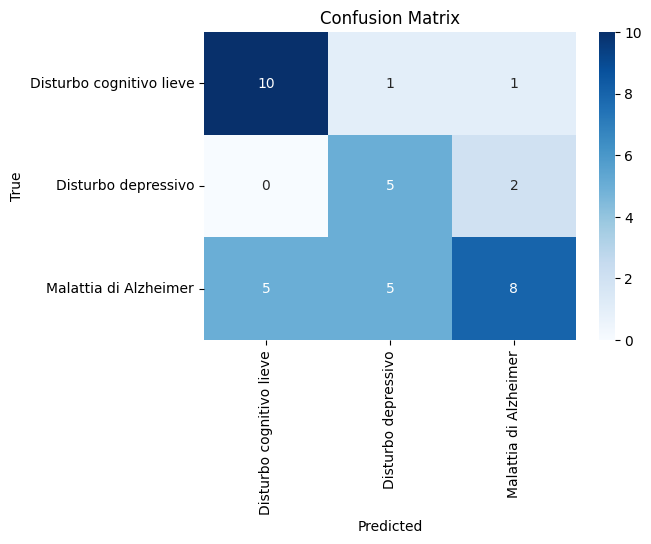

----------------------------------------------------------------------------------------------------

=== Addestramento modello: DecisionTree ===
Fitting 5 folds for each of 72 candidates, totalling 360 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.5988
f1_macro: 0.5905

Best parameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 15}

=== Test set scores ===
Balanced Accuracy: 0.6071
F1 Score (macro): 0.5935
ROC AUC: 0.6956

Classification report:
                           precision    recall  f1-score   support

Disturbo cognitivo lieve       0.64      0.58      0.61        12
     Disturbo depressivo       0.36      0.57      0.44         7
   Malattia di Alzheimer       0.80      0.67      0.73        18

                accuracy                           0.62        37
               macro avg       0.60      0.61      0.59        37
            weighted avg       0.66      

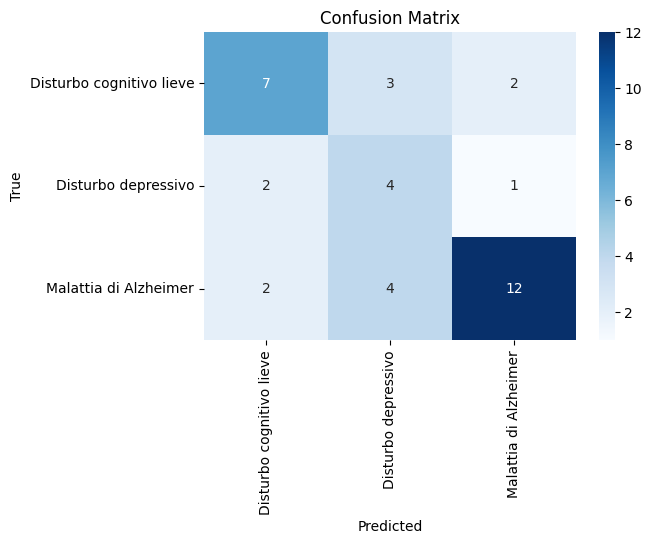

----------------------------------------------------------------------------------------------------

=== Addestramento modello: BalancedRandomForest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.6352
f1_macro: 0.6309

Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}

=== Test set scores ===
Balanced Accuracy: 0.6627
F1 Score (macro): 0.6565
ROC AUC: 0.8799

Classification report:
                           precision    recall  f1-score   support

Disturbo cognitivo lieve       0.64      0.75      0.69        12
     Disturbo depressivo       0.57      0.57      0.57         7
   Malattia di Alzheimer       0.75      0.67      0.71        18

                accuracy                           0.68        37
               macro avg       0.65      0.66      0.66        37
            weighted avg       0

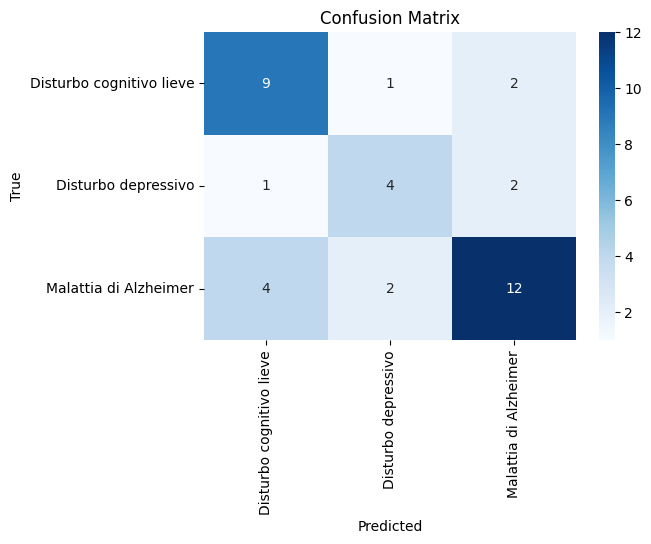

----------------------------------------------------------------------------------------------------

=== Addestramento modello: SVM ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.5157
f1_macro: 0.5028

Best parameters: {'classifier__C': 1, 'classifier__degree': 3, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}

=== Test set scores ===
Balanced Accuracy: 0.5807
F1 Score (macro): 0.5439
ROC AUC: 0.7679

Classification report:
                           precision    recall  f1-score   support

Disturbo cognitivo lieve       0.54      0.58      0.56        12
     Disturbo depressivo       0.45      0.71      0.56         7
   Malattia di Alzheimer       0.62      0.44      0.52        18

                accuracy                           0.54        37
               macro avg       0.54      0.58      0.54        37
            weighted avg       0.56      0.54      0.54        37



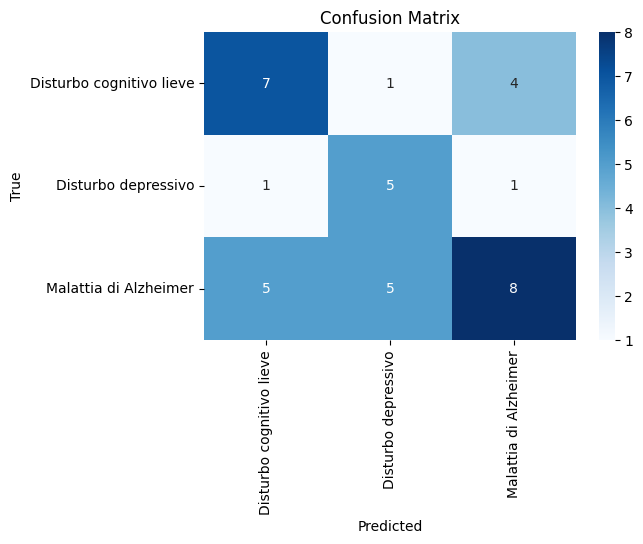

----------------------------------------------------------------------------------------------------

=== Addestramento modello: ExtraTrees ===
Fitting 5 folds for each of 144 candidates, totalling 720 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.6022
f1_macro: 0.6078

Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 15, 'classifier__n_estimators': 100}

=== Test set scores ===
Balanced Accuracy: 0.7116
F1 Score (macro): 0.6778
ROC AUC: 0.8458

Classification report:
                           precision    recall  f1-score   support

Disturbo cognitivo lieve       0.62      0.67      0.64        12
     Disturbo depressivo       0.60      0.86      0.71         7
   Malattia di Alzheimer       0.79      0.61      0.69        18

                accuracy                           0.68        37
               macro avg       0.67      0.71      0.68        37
            weighted avg       0.70      0.6

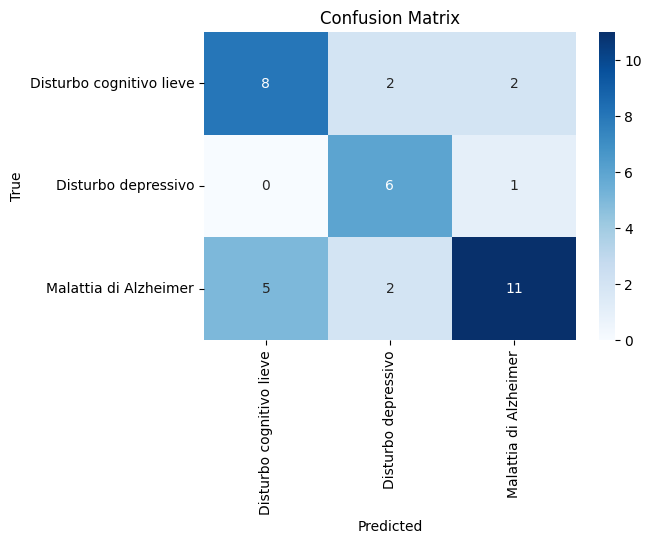

----------------------------------------------------------------------------------------------------

=== Addestramento modello: LGBM ===
Fitting 5 folds for each of 60 candidates, totalling 300 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.6112
f1_macro: 0.6015

Best parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__n_estimators': 200}

=== Test set scores ===
Balanced Accuracy: 0.5767
F1 Score (macro): 0.5627
ROC AUC: 0.8336

Classification report:
                           precision    recall  f1-score   support

Disturbo cognitivo lieve       0.53      0.83      0.65        12
     Disturbo depressivo       0.40      0.29      0.33         7
   Malattia di Alzheimer       0.85      0.61      0.71        18

                accuracy                           0.62        37
               macro avg       0.59      0.58      0.56        37
            weighted avg       0.66      0.62      0.62        37



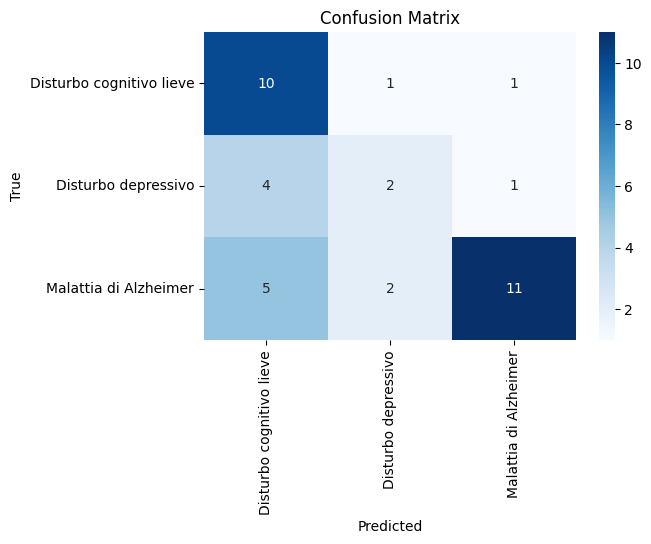

----------------------------------------------------------------------------------------------------

=== Addestramento modello: CatBoost ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.6301
f1_macro: 0.6276

Best parameters: {'classifier__depth': 4, 'classifier__iterations': 300, 'classifier__learning_rate': 0.05}

=== Test set scores ===
Balanced Accuracy: 0.6442
F1 Score (macro): 0.6286
ROC AUC: 0.8291

Classification report:
                           precision    recall  f1-score   support

Disturbo cognitivo lieve       0.56      0.75      0.64        12
     Disturbo depressivo       0.50      0.57      0.53         7
   Malattia di Alzheimer       0.85      0.61      0.71        18

                accuracy                           0.65        37
               macro avg       0.64      0.64      0.63        37
            weighted avg       0.69      0.65      0.65        37



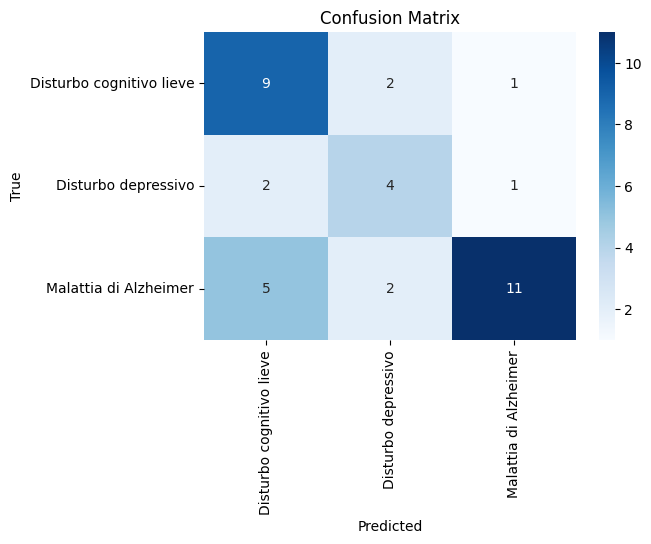

----------------------------------------------------------------------------------------------------

=== Addestramento modello: XGB ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.6605
f1_macro: 0.6430

Best parameters: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 1.0}

=== Test set scores ===
Balanced Accuracy: 0.5119
F1 Score (macro): 0.4958
ROC AUC: 0.7559

Classification report:
                           precision    recall  f1-score   support

Disturbo cognitivo lieve       0.50      0.75      0.60        12
     Disturbo depressivo       0.25      0.29      0.27         7
   Malattia di Alzheimer       0.82      0.50      0.62        18

                accuracy                           0.54        37
               macro avg       0.52      0.51      0.50        37
            weighted a

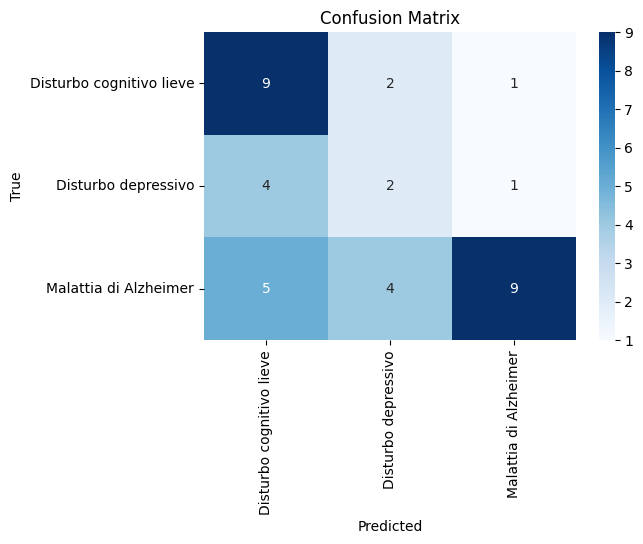

----------------------------------------------------------------------------------------------------


In [8]:
# Dizionario dei modelli e delle loro griglie di parametri
models = {
    'WeightedKNN':{
        'model': KNeighborsClassifier(weights='distance'),
        'param_grid': {
            'classifier__n_neighbors': [3, 5, 7, 9, 11, 13],
            'classifier__metric': ['minkowski', 'euclidean', 'manhattan'],
            'classifier__p': [1, 2],
        }
    },

    'DecisionTree':{
        'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'param_grid': {
            'classifier__max_depth': [5, 10, 15, None],
            'classifier__min_samples_split': [5, 10, 15],
            'classifier__min_samples_leaf': [2, 4, 8],
            'classifier__criterion': ['gini', 'entropy'],
        }
    },

    'BalancedRandomForest':{
        'model': BalancedRandomForestClassifier(random_state=42, replacement=True),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [None, 10, 20, 30],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4],
        }
    },

    'SVM':{
        'model': SVC(class_weight='balanced', probability=True, random_state=42),
        'param_grid': {
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf', 'poly'],
        'classifier__gamma': ['scale', 'auto'],  # solo per 'rbf' e 'poly'
        'classifier__degree': [3, 4],  # solo per 'poly'
        }
    },

    'ExtraTrees': {
        'model': ExtraTreesClassifier(random_state=42, class_weight='balanced'),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 150, 200],
            'classifier__max_depth': [None, 5, 10, 15],
            'classifier__min_samples_split': [5, 10, 15],
            'classifier__min_samples_leaf': [1, 2, 4],
        }
    },

    'LGBM':{
        'model': LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 150, 200],
            'classifier__learning_rate':  [0.01, 0.05, 0.1],
            'classifier__max_depth': [-1, 3, 5, 7, 10],
        }
    },

    'CatBoost':{
        'model': None,  # sarà definito nel ciclo
        'param_grid':{
            'classifier__iterations': [300, 500],
            'classifier__depth': [4, 8],
            'classifier__learning_rate': [0.01, 0.05],
        }
    },

    'XGB':{
        'model': None,  # sarà definito nel ciclo
        'param_grid': {
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [3, 6, 10],
            'classifier__learning_rate': [0.01, 0.05, 0.1],
            'classifier__subsample': [0.8, 1.0],
            'classifier__colsample_bytree': [0.8, 1.0],
        }
    }
}

scoring = {
    'balanced_accuracy': make_scorer(balanced_accuracy_score),
    'f1_macro': make_scorer(f1_score, average='macro')
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Ciclo sui modelli
for name, m in models.items():
    print(f"\n=== Addestramento modello: {name} ===")

    # Inizializzazione dinamica dei modelli in base al tipo di classificazione
    if name == 'XGB':
        if is_multiclass:
            model = XGBClassifier(
                objective='multi:softprob',
                num_class=len(np.unique(y_train)),
                eval_metric='mlogloss',
                random_state=42
            )
        else:
            model = XGBClassifier(
                objective='binary:logistic',
                eval_metric='logloss',
                random_state=42
            )
    elif name == 'CatBoost':
        model = CatBoostClassifier(
            loss_function='MultiClass' if is_multiclass else 'Logloss',
            random_seed=42,
            verbose=0
        )
    else:
        model = m['model']

    pipeline = build_pipeline(model)

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=m['param_grid'],
        scoring=scoring,
        refit='balanced_accuracy',
        cv=cv,
        n_jobs=-1,
        verbose=2,
        return_train_score=True,
        error_score='raise'
    )

    # Gestione dell'etichettatura per XGB (richiede label numeriche)
    if name == 'XGB':
        le = LabelEncoder()
        y_train_encoded = le.fit_transform(y_train)
        y_test_encoded = le.transform(y_test)

        search.fit(X_train, y_train_encoded)

        class_labels = le.classes_
        evaluate_model(search, X_test, y_test, class_labels, le=le, is_multiclass=is_multiclass)

    else:
        search.fit(X_train, y_train)
        class_labels = search.best_estimator_.named_steps['classifier'].classes_
        evaluate_model(search, X_test, y_test, class_labels, is_multiclass=is_multiclass)

    print("-"*100)
